# Downscaling bias explainer

Forked from [`pipeline-stage-debugger.ipynb`](../../../docs/how-to/pipeline-stage-debugger.ipynb) — this
notebook replicates the same Stage 1 + Stage 2 steps (through the `downscaled`
Cell E result) but drops the per-step QA-check/plotting scaffolding (`inspect()`),
since the point here isn't stage-by-stage debugging, it's understanding *why*
downscaled has the bias it does relative to observations.

Two parts:

1. **Bias summary grid** — mean bias of the bias-correction step
   (bias-corrected vs. coarsened obs) and the downscaling step (downscaled vs.
   observed), in both absolute and percent form.
2. **Does the DOY climatology capture the right seasonal cycle?** — not bias,
   but shape: does `obs_fine_doy_means` (the FFT-smoothed fine-grid
   climatology the downscaling math is built on) trace the same seasonal
   cycle as `obs_fine_doy_means_simple` (the unsmoothed empirical DOY mean)
   and as `obs_coarse_doy_means` (regridded back to the fine grid)? Scored
   with R² and an anomaly-based Nash–Sutcliffe efficiency — both blind to a
   plain level bias, so what they pick up is purely pattern mismatch.

**Not executed here** — the data isn't accessible from this machine. Run this
on a cluster with S3/catalog access.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray as xr
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from saidownscale.downscaling_config import DownscalingConfig, PipelineOptions
from saidownscale.downscaling_utils import (
    calculate_doy_means,
    get_historical_experiment,
    get_obs,
    interpolate_coarse_to_fine_grid,
    interpolate_fine_to_coarse_grid,
    subset_space,
)
from saidownscale.pipeline import DownscalingPipeline

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    _HAS_CARTOPY = True
except ImportError:
    _HAS_CARTOPY = False

warnings.filterwarnings("ignore", category=FutureWarning)

## Config

Same defaults as `pipeline-stage-debugger.ipynb` (Southern Africa subset,
`CESM2-WACCM` / `pr`, historical only — `SCENARIO = None` since this analysis
only needs Stage 1 + Stage 2). Edit as needed for the run.

In [2]:
# ── Edit these values ──────────────────────────────────────────────────────────
GCM = "CESM2-WACCM"
VARIABLE = "pr"
ENSEMBLE_MEMBER = "r3i1p1f1"  # CESM2-WACCM SSP245/G6-1.5K uses numeric IDs; "001" → hist r1i1p1f1
SCENARIO = None  # this notebook only needs Stage 1 + Stage 2 (through `downscaled`)

# Southern Africa including high spot in Angola.
# (lat_min, lat_max, lon_min, lon_max)
SUBSET_BOUNDS = (-5, 16, 33, 55)

# ──────────────────────────────────────────────────────────────────────────────

config = DownscalingConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    subset_bounds=SUBSET_BOUNDS,
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug",
    environment="debug",
)
pipeline = DownscalingPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")

Run: CESM2-WACCM_pr_r3i1p1f1_subset
Subset bounds: (-5.0, 16.0, 33.0, 55.0)


## Stage 1 — `prepare_observations`

Same steps as the debugger notebook, without the `inspect()` QA/plotting
overhead — we just need `obs_coarse` written to the debug cache so Stage 2's
`_load_gcm_obs()` can find it.

In [3]:
# ── obs_fine: fine-resolution ERA5 observations ───────────────────────────────
obs_fine = get_obs(var=config.variable, dataset_name=config.obs_dataset)
obs_fine = obs_fine.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    obs_fine = subset_space(obs_fine, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max))
train_slice = slice(str(config.train_period_start), str(config.train_period_end))
obs_fine = obs_fine.sel(time=train_slice).compute()
print(f"obs_fine: {dict(obs_fine.sizes)}")

obs_fine: {'time': 13514, 'lat': 85, 'lon': 89}


In [4]:
# ── model_grid: GCM historical run (used only as a coarse grid template) ──────
model_grid = get_historical_experiment(
    gcm=config.gcm, member=pipeline._hist_member, var=config.variable
)
model_grid = model_grid.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    model_grid = subset_space(
        model_grid, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max)
    )
model_grid = model_grid.sel(time=train_slice).compute()
print(f"model_grid: {dict(model_grid.sizes)}")

model_grid: {'time': 13514, 'lat': 22, 'lon': 18}


In [5]:
# ── obs_coarse_stage1: ERA5 obs regridded to the GCM coarse grid ──────────────
obs_coarse_stage1 = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=model_grid
).compute()
print(f"obs_coarse_stage1: {dict(obs_coarse_stage1.sizes)}")

obs_coarse_stage1: {'time': 13514, 'lat': 22, 'lon': 18}


In [6]:
%%time
# ── Write to debug cache so Stage 2 _load_gcm_obs() can find obs_regridded ───
# force=True overwrites any previous debug-branch artifact.
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
prepare_obs_path = pipeline.prepare_observations(force=True)
print(f"  → {prepare_obs_path}")

Writing obs_coarse to debug cache via prepare_observations(force=True) ...


  2026-07-30T00:11:49.746563Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-07-30T00:11:50.084363Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



  → /tmp/bcsd-debug/scratch/debug/CESM2-WACCM-ERA5-lat-5.0to16.0_lon33.0to55.0.icechunk
CPU times: user 3min, sys: 1min 3s, total: 4min 3s
Wall time: 32.1 s


## Stage 2 — `fit_historical` (debiasing + spatial downscaling)

Replicates Cells A–E of the debugger notebook's spatial-disaggregation
sub-steps exactly, ending at `downscaled`.

In [7]:
%%time
# ── _load_gcm_obs: reload from debug cache + load obs_fine, model_hist ────────
obs_coarse, obs_fine_s2, model_hist = pipeline._load_gcm_obs()
obs_coarse = obs_coarse.compute()
obs_fine_s2 = obs_fine_s2.compute()
model_hist = model_hist.compute()
print(f"obs_coarse:  {dict(obs_coarse.sizes)}")
print(f"obs_fine_s2: {dict(obs_fine_s2.sizes)}")
print(f"model_hist:  {dict(model_hist.sizes)}")

  2026-07-30T00:12:21.866028Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-07-30T00:12:21.867219Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



obs_coarse:  {'time': 13514, 'lat': 22, 'lon': 18}
obs_fine_s2: {'time': 13514, 'lat': 85, 'lon': 89}
model_hist:  {'time': 13514, 'lat': 22, 'lon': 18}
CPU times: user 1min 40s, sys: 33.7 s, total: 2min 13s
Wall time: 15.2 s


In [8]:
%%time
# ── _apply_bias_correction: ibicus QuantileMapping on historical period ────────
debiased_coarse = pipeline._apply_bias_correction(obs_coarse, model_hist).compute()
print(f"debiased_coarse: {dict(debiased_coarse.sizes)}")

debiased_coarse: {'time': 13514, 'lat': 22, 'lon': 18}
CPU times: user 135 ms, sys: 13.7 s, total: 13.8 s
Wall time: 15.3 s


In [9]:
%%time
# ── Cell A: fine-grid day-of-year climatology (FFT-smoothed, production default) ──
# allow_negative_values=False mirrors production (_apply_spatial_downscaling).
obs_fine_doy_means = calculate_doy_means(
    obs_fine_s2,
    clim_method=config.variable_config.downscaling_clim_method,
    allow_negative_values=False,
).compute()
print(f"obs_fine_doy_means: {dict(obs_fine_doy_means.sizes)}")

obs_fine_doy_means: {'dayofyear': 366, 'lat': 85, 'lon': 89}
CPU times: user 759 ms, sys: 28.3 ms, total: 788 ms
Wall time: 521 ms


In [10]:
# ── Cell A' (kept in memory for Part 2 below): unsmoothed / simple DOY climatology ──
obs_fine_doy_means_simple = calculate_doy_means(obs_fine_s2, clim_method="simple").compute()
print(f"obs_fine_doy_means_simple: {dict(obs_fine_doy_means_simple.sizes)}")

obs_fine_doy_means_simple: {'dayofyear': 366, 'lat': 85, 'lon': 89}


In [11]:
# ── Cell B: coarsen DOY climatology to GCM grid ───────────────────────────────
obs_coarse_doy_means = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine_doy_means, da_coarse_grid=obs_coarse
).compute()
print(f"obs_coarse_doy_means: {dict(obs_coarse_doy_means.sizes)}")

obs_coarse_doy_means: {'dayofyear': 366, 'lat': 22, 'lon': 18}


In [12]:
# ── Cell C: coarse spatial residuals (debiased vs coarse climatology) ─────────
if config.variable_config.downscaling_method == "additive":
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") - obs_coarse_doy_means
elif config.variable_config.downscaling_method == "multiplicative":
    # Zero-guarded ratio + clip, mirrors downscale_from_coarse() production behavior.
    max_residual = 100
    zero_clim = obs_coarse_doy_means == 0
    safe_clim = obs_coarse_doy_means.where(~zero_clim)  # zeros -> NaN
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") / safe_clim
    zero_clim_on_time = zero_clim.sel(dayofyear=debiased_coarse["time"].dt.dayofyear)
    residuals_coarse = residuals_coarse.where(~zero_clim_on_time, 0.0).clip(max=max_residual)
residuals_coarse = residuals_coarse.compute()
print(f"residuals_coarse: {dict(residuals_coarse.sizes)}")

residuals_coarse: {'time': 13514, 'lat': 22, 'lon': 18}


In [13]:
# ── Cell D: interpolate residuals to fine grid ────────────────────────────────
residuals_fine = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=residuals_coarse, da_fine_grid=obs_fine_s2
).compute()
print(f"residuals_fine: {dict(residuals_fine.sizes)}")

residuals_fine: {'time': 13514, 'lat': 85, 'lon': 89}


In [14]:
# ── Cell E: reapply fine-grid DOY climatology → final downscaled field ─────────
if config.variable_config.downscaling_method == "additive":
    downscaled = residuals_fine.groupby("time.dayofyear") + obs_fine_doy_means
elif config.variable_config.downscaling_method == "multiplicative":
    downscaled = residuals_fine.groupby("time.dayofyear") * obs_fine_doy_means
downscaled = downscaled.compute()
print(f"downscaled: {dict(downscaled.sizes)}")

downscaled: {'time': 13514, 'lat': 85, 'lon': 89}


---

## Part 1 — Bias summary grid

Two pipeline steps each introduce their own bias relative to some observed
reference:

- **Bias correction** (coarse grid): `debiased_coarse` vs. `obs_coarse` — did
  quantile mapping actually remove the GCM's mean bias?
- **Downscaling** (fine grid): `downscaled` vs. `obs_fine_s2` — does spatial
  disaggregation preserve that (un)bias once it's spread onto the fine grid?

Layout is 4 columns × 2 rows (7 panels; the cell under "Raw GCM" is blank,
since there's no fine-resolution analog of the pre-bias-correction raw GCM
field):

| | col 1 | col 2 | col 3 | col 4 |
|---|---|---|---|---|
| **row 1** (coarse) | Raw GCM | Bias-corrected | Coarsened obs | Bias-corrected − coarsened obs |
| **row 2** (fine) | *(blank)* | Downscaled | Observed | Downscaled − observed |

Both absolute and percent-of-obs versions are plotted.

In [15]:
raw_mean = model_hist.mean("time").compute()
bias_corrected_mean = debiased_coarse.mean("time").compute()
coarse_obs_mean = obs_coarse.mean("time").compute()

downscaled_mean = downscaled.mean("time").compute()
fine_obs_mean = obs_fine_s2.mean("time").compute()

bias_correction_diff = (bias_corrected_mean - coarse_obs_mean).compute()
bias_correction_pdiff = (bias_correction_diff / coarse_obs_mean * 100).compute()

downscaling_diff = (downscaled_mean - fine_obs_mean).compute()
downscaling_pdiff = (downscaling_diff / fine_obs_mean * 100).compute()

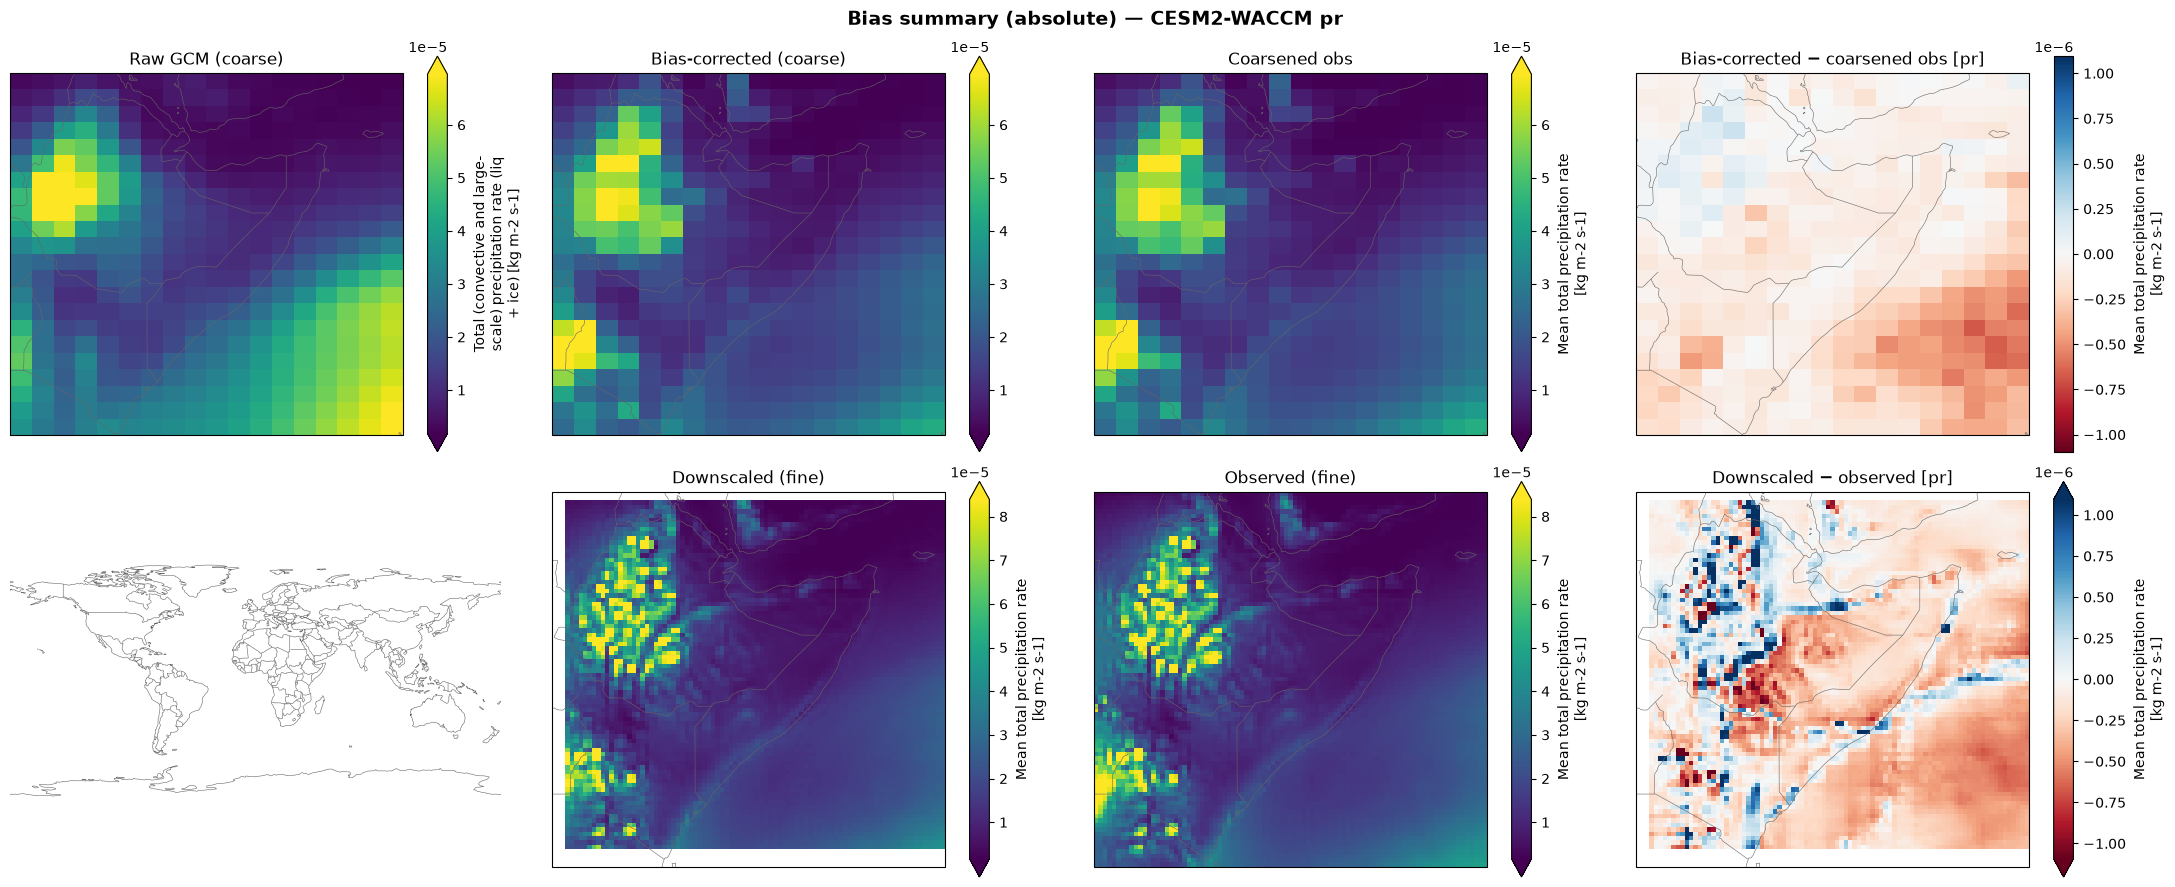

In [16]:
def _add_coastlines(ax):
    if _HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.4")


def plot_bias_grid(mode: str = "absolute") -> None:
    """4-column x 2-row bias summary; see markdown above for the layout.

    `mode`: "absolute" (native units) or "percent" (% of the reference obs mean).
    """
    if mode not in ("absolute", "percent"):
        raise ValueError(f"mode must be 'absolute' or 'percent', got {mode!r}")

    subplot_kw = {"projection": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(2, 4, figsize=(22, 9), subplot_kw=subplot_kw)

    # ── shared value color-scale per row (robust quantiles, not the hard min/max) ──
    coarse_vmin = float(
        min(v.quantile(0.02) for v in (raw_mean, bias_corrected_mean, coarse_obs_mean))
    )
    coarse_vmax = float(
        max(v.quantile(0.98) for v in (raw_mean, bias_corrected_mean, coarse_obs_mean))
    )
    fine_vmin = float(min(v.quantile(0.02) for v in (downscaled_mean, fine_obs_mean)))
    fine_vmax = float(max(v.quantile(0.98) for v in (downscaled_mean, fine_obs_mean)))

    value_kw = {"add_colorbar": True}
    if _HAS_CARTOPY:
        value_kw["transform"] = ccrs.PlateCarree()

    raw_mean.plot(ax=axes[0, 0], vmin=coarse_vmin, vmax=coarse_vmax, **value_kw)
    axes[0, 0].set_title("Raw GCM (coarse)")

    bias_corrected_mean.plot(ax=axes[0, 1], vmin=coarse_vmin, vmax=coarse_vmax, **value_kw)
    axes[0, 1].set_title("Bias-corrected (coarse)")

    coarse_obs_mean.plot(ax=axes[0, 2], vmin=coarse_vmin, vmax=coarse_vmax, **value_kw)
    axes[0, 2].set_title("Coarsened obs")

    axes[1, 0].axis("off")

    downscaled_mean.plot(ax=axes[1, 1], vmin=fine_vmin, vmax=fine_vmax, **value_kw)
    axes[1, 1].set_title("Downscaled (fine)")

    fine_obs_mean.plot(ax=axes[1, 2], vmin=fine_vmin, vmax=fine_vmax, **value_kw)
    axes[1, 2].set_title("Observed (fine)")

    if mode == "absolute":
        coarse_diff, fine_diff, label = bias_correction_diff, downscaling_diff, config.variable
    else:
        coarse_diff, fine_diff, label = bias_correction_pdiff, downscaling_pdiff, "%"

    diff_vmax = float(max(abs(coarse_diff).quantile(0.98), abs(fine_diff).quantile(0.98)))
    diff_kw = {"cmap": "RdBu", "vmin": -diff_vmax, "vmax": diff_vmax, "add_colorbar": True}
    if _HAS_CARTOPY:
        diff_kw["transform"] = ccrs.PlateCarree()

    coarse_diff.plot(ax=axes[0, 3], **diff_kw)
    axes[0, 3].set_title(f"Bias-corrected − coarsened obs [{label}]")

    fine_diff.plot(ax=axes[1, 3], **diff_kw)
    axes[1, 3].set_title(f"Downscaled − observed [{label}]")

    for ax in axes.flat:
        _add_coastlines(ax)

    fig.suptitle(
        f"Bias summary ({mode}) — {config.gcm} {config.variable}", fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


plot_bias_grid("absolute")

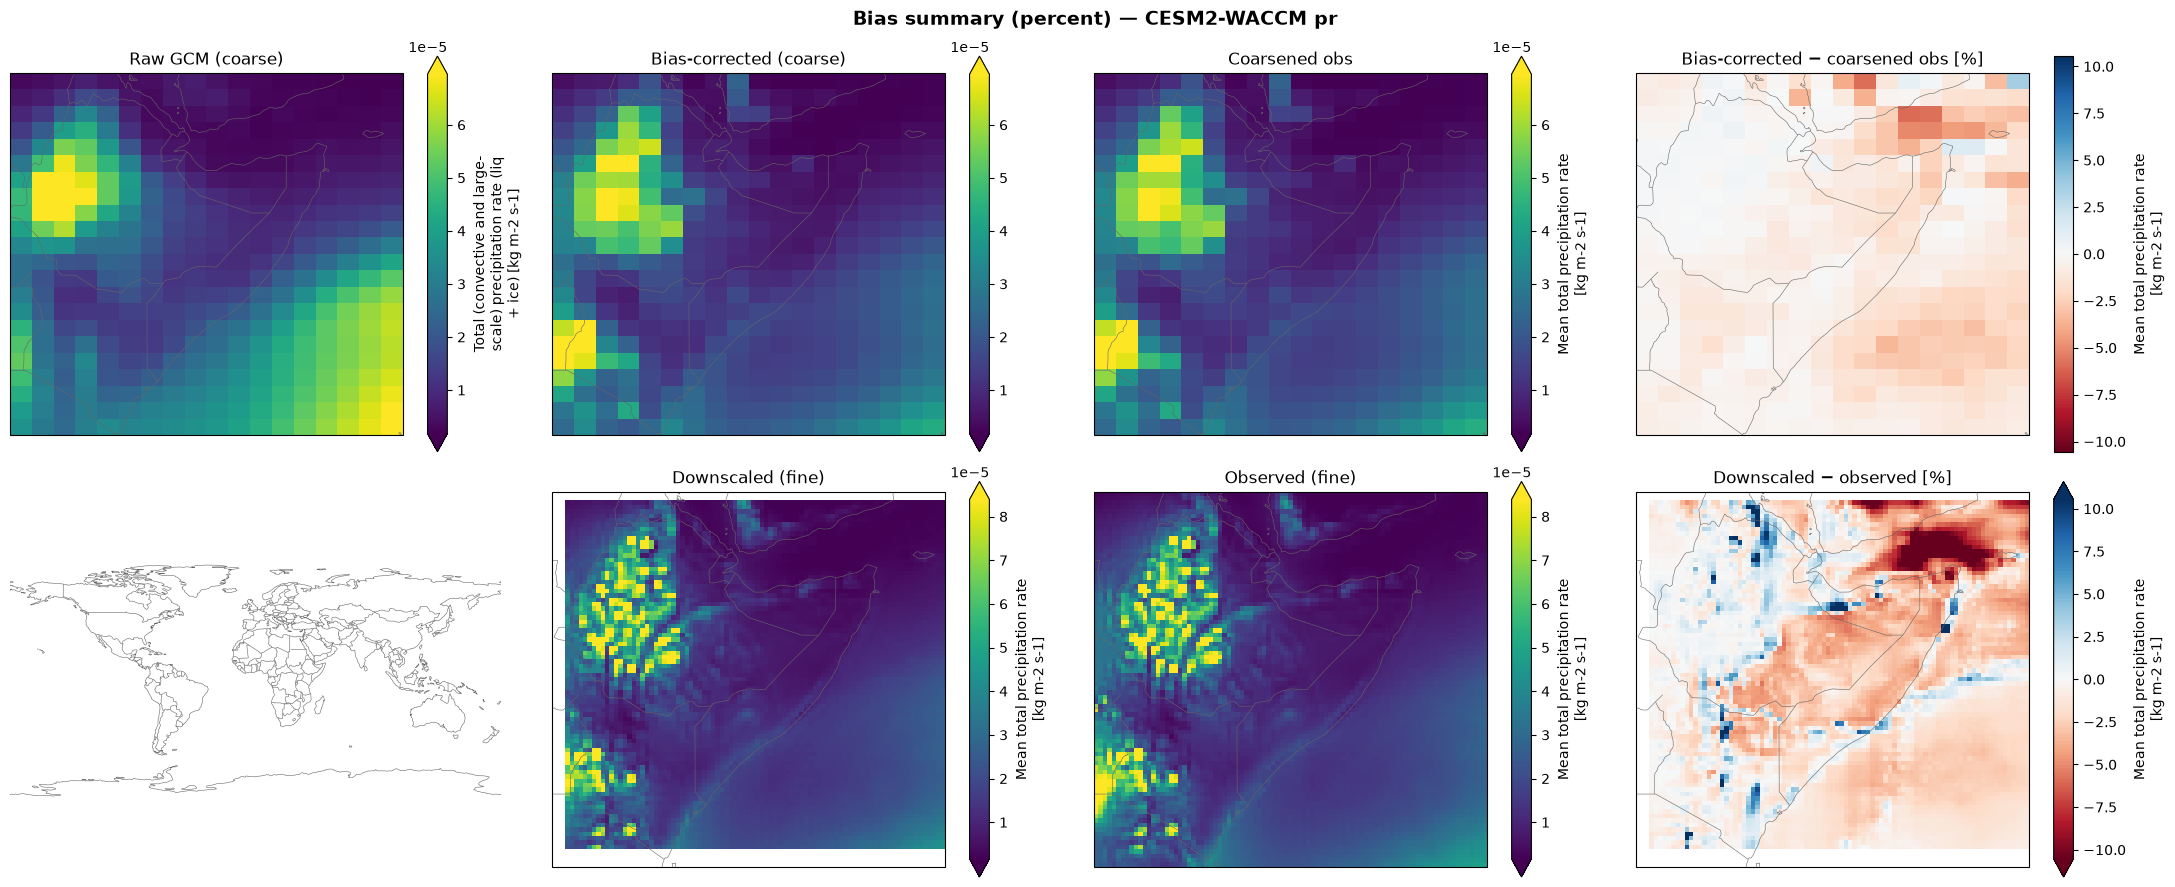

In [17]:
plot_bias_grid("percent")

---

## Part 2 — Does `obs_fine_doy_means` capture the right seasonal *cycle*?

Rather than looking at bias (a level/magnitude difference), this section asks
a shape question: at each pixel, does the FFT-smoothed climatology
(`obs_fine_doy_means`) trace out the same seasonal cycle — the same pattern
of ups and downs through the year — as two references it should agree with?

- **`obs_fine_doy_means_simple`** — the unsmoothed empirical DOY mean at the
  same (fine) resolution. Disagreement here is purely an FFT-fitting
  artifact, since both are computed from the same fine-grid obs.
- **`obs_coarse_doy_means`** (nearest-neighbor regridded back to the fine
  grid) — the climatology `debiased_coarse` is actually divided/subtracted by
  at Cell C. Disagreement here is what the coarse grid's spatial averaging
  costs relative to the fine-resolution cycle.

Two shape-focused stats per pixel, computed over the `dayofyear` dimension:

- **R²** — squared Pearson correlation between the two curves. Purely about
  *pattern*: two curves that are perfectly in sync but offset by a constant
  (or scaled by a constant factor) still score R² = 1.
- **NSE (anomaly)** — Nash–Sutcliffe efficiency computed *after* subtracting
  each curve's own annual mean first, so a systematic level difference
  between the two curves doesn't penalize the score either. 1 = perfect
  shape match, 0 = no better than predicting a flat line, negative = worse
  than that.

Neither metric can be fooled by a plain bias — that's the point.

In [18]:
def seasonal_cycle_skill(
    reference: xr.DataArray, comparison: xr.DataArray, dim: str = "dayofyear"
) -> xr.Dataset:
    """Per-pixel shape agreement between two dayofyear-indexed climatologies.

    Both metrics are computed on de-meaned (anomaly) curves, so a constant
    offset between `reference` and `comparison` — a bias — never shows up
    here; only the shape of the seasonal cycle does.
    """
    ref_anom = reference - reference.mean(dim)
    comp_anom = comparison - comparison.mean(dim)

    r2 = (xr.corr(reference, comparison, dim=dim) ** 2).rename("r2")

    ss_res = ((comp_anom - ref_anom) ** 2).sum(dim)
    ss_tot = (ref_anom**2).sum(dim)
    nse_anomaly = (1 - ss_res / ss_tot).rename("nse_anomaly")

    return xr.Dataset({"r2": r2, "nse_anomaly": nse_anomaly})


def plot_seasonal_cycle_skill(skill: xr.Dataset, title: str) -> None:
    # subplot_kw + transform are required together — without a GeoAxes
    # (projection=...), ax.add_feature() in _add_coastlines() would fail.
    subplot_kw = {"projection": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    plot_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw=subplot_kw)
    skill["r2"].plot(ax=axes[0], vmin=0, vmax=1, cmap="viridis", **plot_kw)
    axes[0].set_title("R² (shape/pattern match)")
    skill["nse_anomaly"].plot(
        ax=axes[1], vmin=0, vmax=1, cmap="viridis", cbar_kwargs={"extend": "min"}, **plot_kw
    )
    axes[1].set_title("NSE, anomaly (shape + relative amplitude match)")
    for ax in axes:
        _add_coastlines(ax)
    fig.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

### 2a — `obs_fine_doy_means` vs. `obs_fine_doy_means_simple` (FFT fit vs. raw empirical cycle)

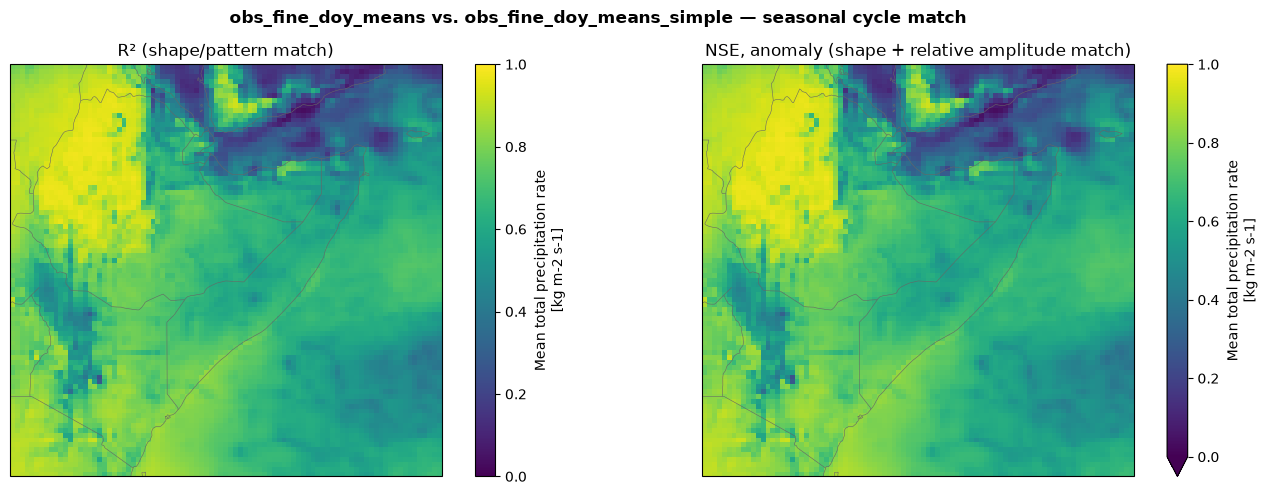

In [19]:
fft_vs_simple_skill = seasonal_cycle_skill(
    reference=obs_fine_doy_means_simple, comparison=obs_fine_doy_means
).compute()

plot_seasonal_cycle_skill(
    fft_vs_simple_skill, "obs_fine_doy_means vs. obs_fine_doy_means_simple — seasonal cycle match"
)

### 2b — `obs_fine_doy_means` vs. `obs_coarse_doy_means` (nearest-neighbor regridded to the fine grid)

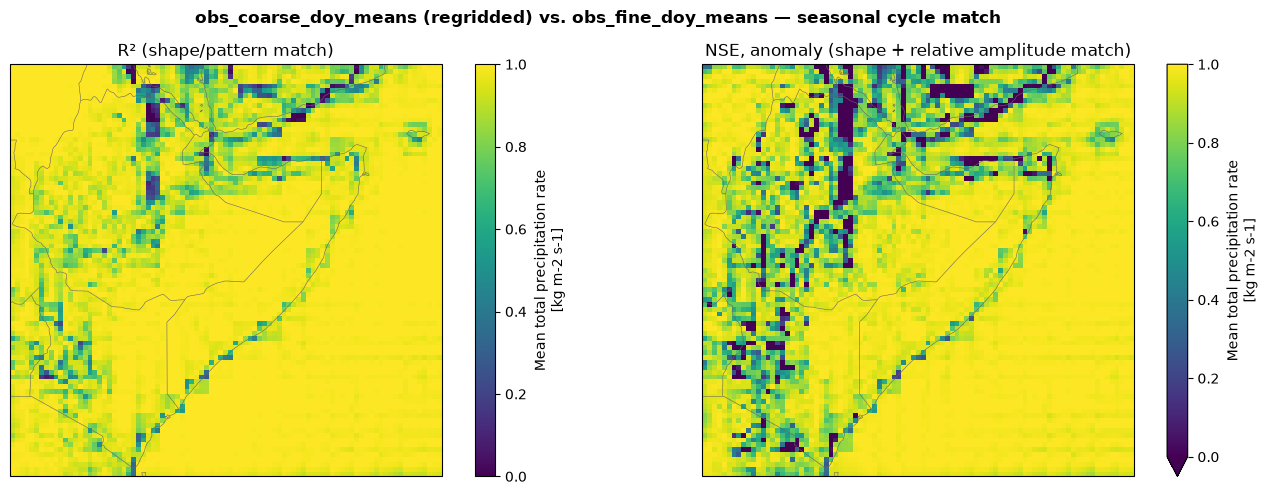

In [20]:
# `.sel(..., method="nearest")` keeps the *coarse* grid's snapped coordinate
# labels, not the fine grid's — reassign them so this aligns with
# obs_fine_doy_means for arithmetic/masking.
obs_coarse_doy_means_on_fine = obs_coarse_doy_means.sel(
    lat=obs_fine_doy_means.lat, lon=obs_fine_doy_means.lon, method="nearest"
).assign_coords(lat=obs_fine_doy_means.lat, lon=obs_fine_doy_means.lon)

fine_vs_coarse_skill = seasonal_cycle_skill(
    reference=obs_fine_doy_means, comparison=obs_coarse_doy_means_on_fine
).compute()

plot_seasonal_cycle_skill(
    fine_vs_coarse_skill,
    "obs_coarse_doy_means (regridded) vs. obs_fine_doy_means — seasonal cycle match",
)

---

## Part 3 — DOY climatology grid: the high-bias pixel and its 8 neighbors

DOY comparison laid out as a 3×3 spatial grid centered on a high-bias pixel (`lat=2.500,
lon=45.500`), with its immediate neighbors arranged the same way they sit on
the map — north at the top, south at the bottom, west on the left, east on
the right — so it's immediately visible whether the bias is isolated to
this one pixel or shared with its neighborhood.

Each panel's title reports that pixel's `downscaled − observed` bias in
**bold, colored on the same red(high)/blue(low) scale as the Part 1 bias
maps** (with a light matching highlight behind the text) — so the
worst-offending pixel(s) jump out immediately without having to read the
numbers.

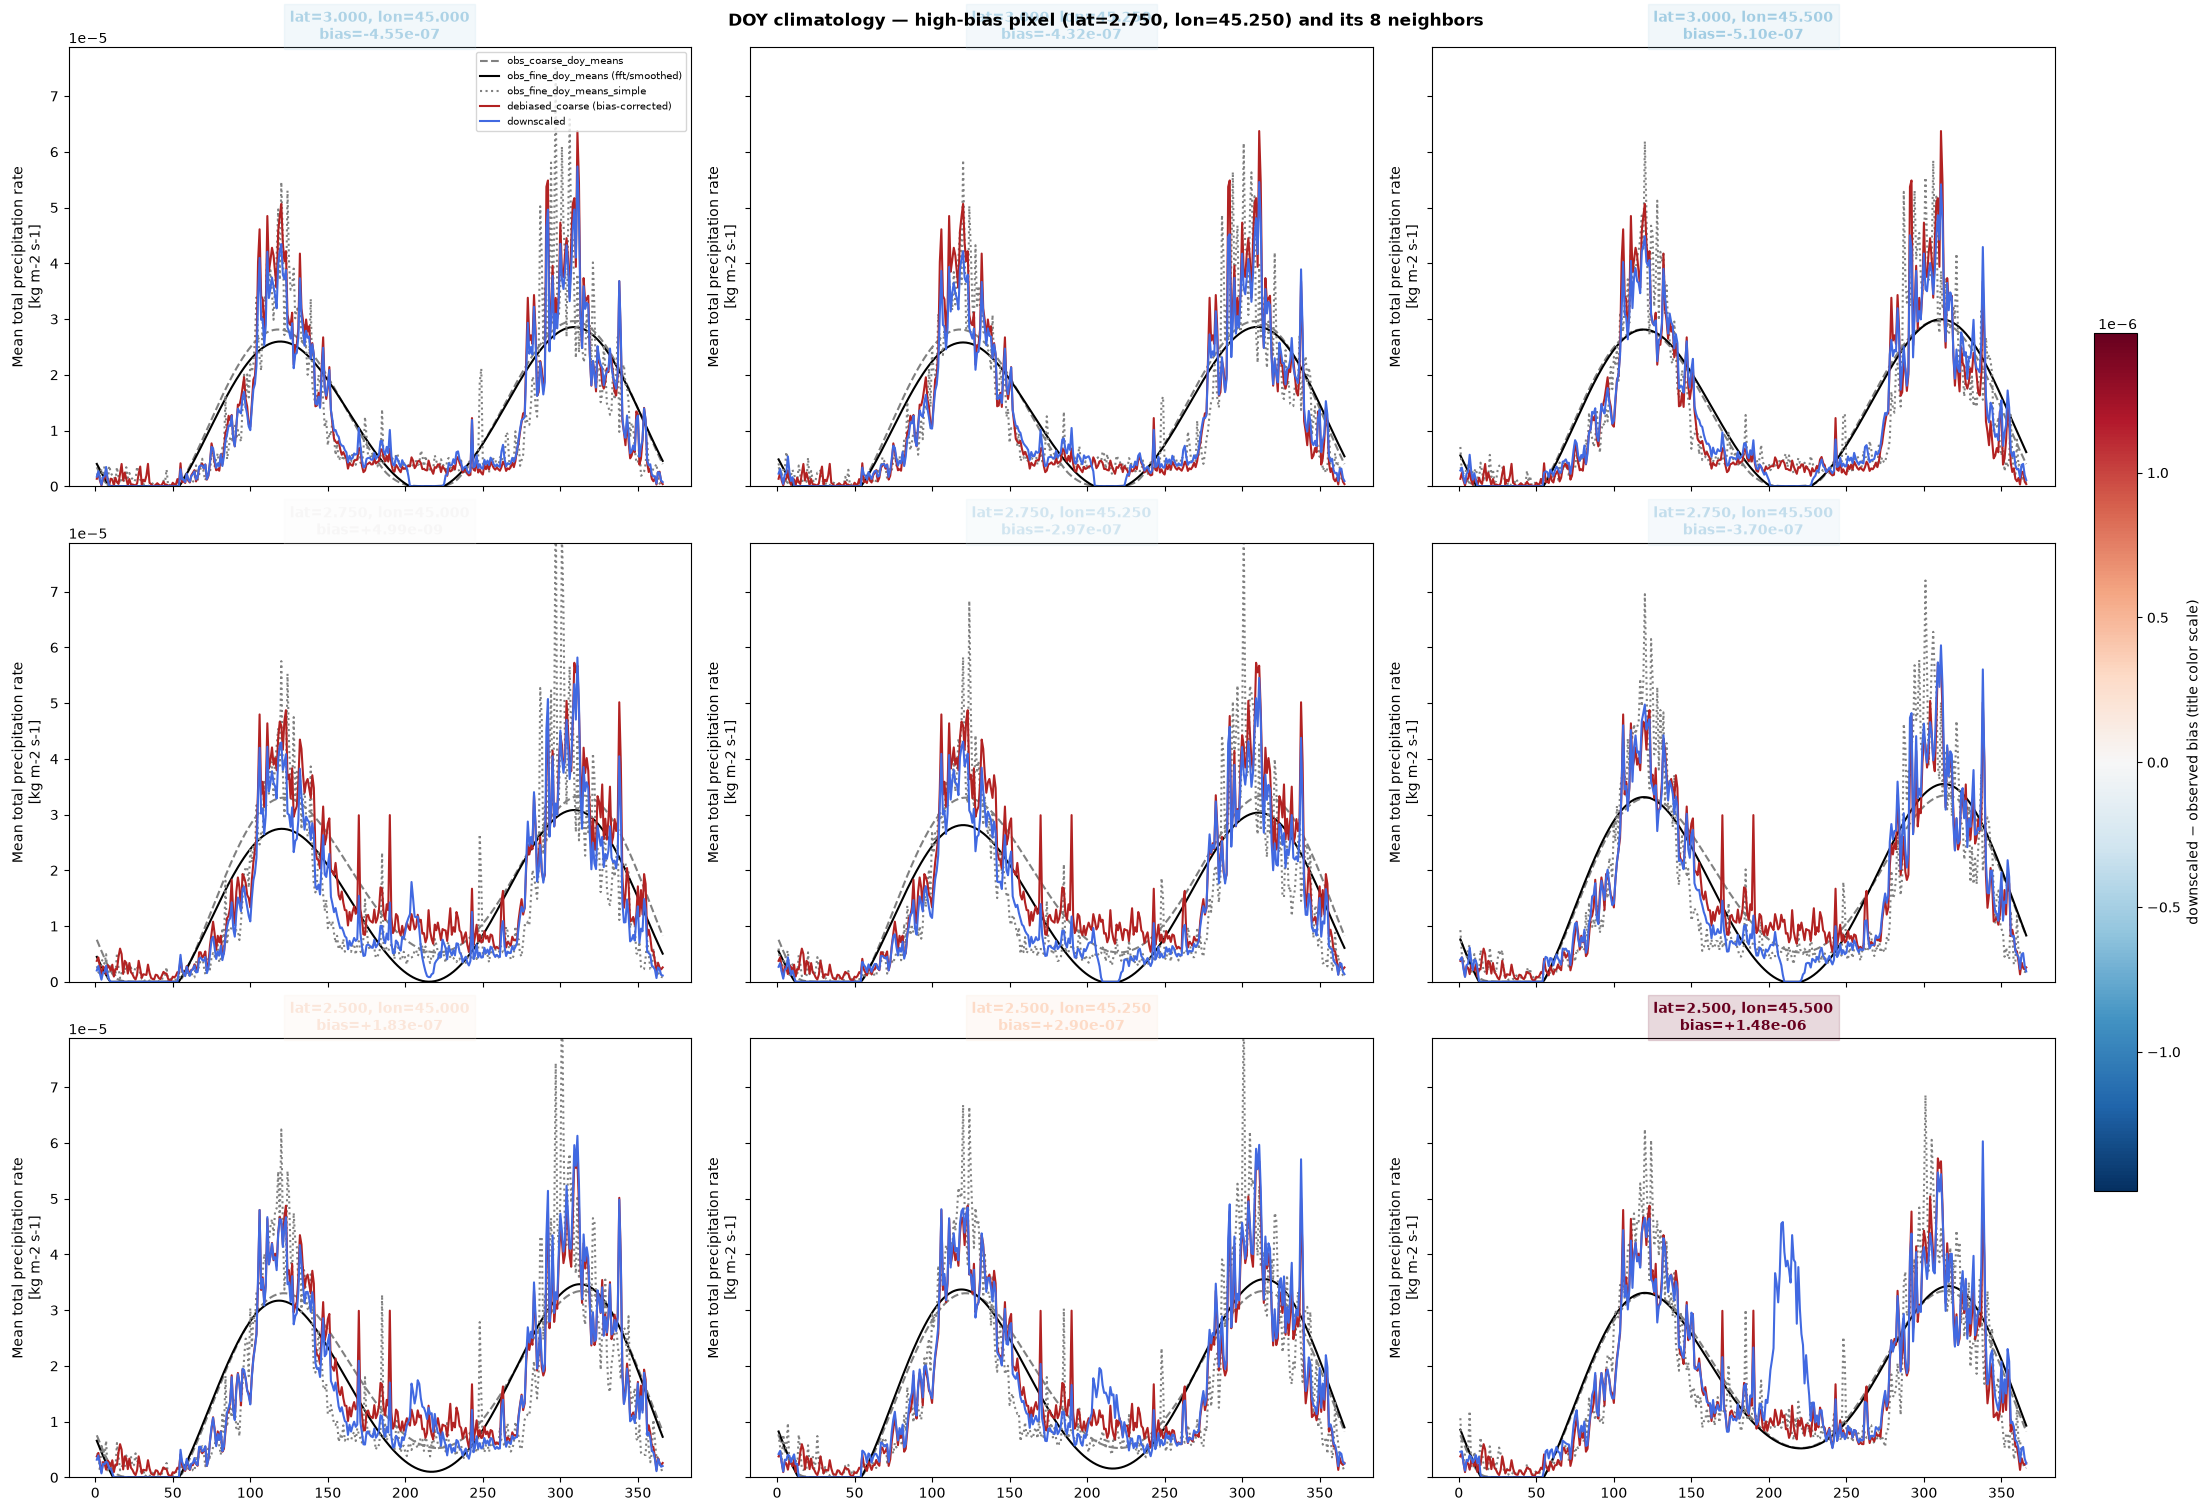

In [25]:
FOCUS_LAT, FOCUS_LON = 2.7500, 45.2500  # the high-bias pixel identified in Part 3
# FOCUS_LAT, FOCUS_LON = 7.500, 52.00 # another high-bias pixel of a different flavor

# Neighbor spacing from the fine grid's own coordinate spacing — robust to
# either ascending or descending lat/lon storage order, since offsets are
# applied to the numeric coordinate value, not the array index.
lat_step = float(np.median(np.abs(np.diff(downscaled["lat"].values))))
lon_step = float(np.median(np.abs(np.diff(downscaled["lon"].values))))

# Row/col layout mirrors the map: north (top) -> south (bottom), west (left) -> east (right).
grid_offsets = [
    [(+1, -1), (+1, 0), (+1, +1)],  # NW, N,  NE
    [(0, -1), (0, 0), (0, +1)],  #      W, center, E
    [(-1, -1), (-1, 0), (-1, +1)],  # SW, S,  SE
]

# ── Pass 1: resolve each panel's actual pixel + bias first, so panel titles ──
# can be colored on a scale shared across all 9 panels (a bias of the same
# magnitude should look equally "loud" no matter which panel it's in).
panels = []
for offset_row in grid_offsets:
    panel_row = []
    for dlat, dlon in offset_row:
        req_lat, req_lon = FOCUS_LAT + dlat * lat_step, FOCUS_LON + dlon * lon_step
        # Snap to the pixel's *actual* fine-grid coordinate labels (not the
        # requested lat/lon) so the title/bias lookup can't silently drift
        # onto the wrong cell.
        fine_pixel = downscaled.sel(lat=req_lat, lon=req_lon, method="nearest")
        actual_lat, actual_lon = float(fine_pixel["lat"]), float(fine_pixel["lon"])
        bias_val = float(downscaling_diff.sel(lat=actual_lat, lon=actual_lon, method="nearest"))
        panel_row.append({"lat": actual_lat, "lon": actual_lon, "bias": bias_val})
    panels.append(panel_row)

bias_vmax = max(abs(p["bias"]) for row in panels for p in row)
bias_norm = plt.Normalize(vmin=-bias_vmax, vmax=bias_vmax)
bias_cmap = plt.cm.RdBu_r  # matches the bias maps in Part 1: red = high bias, blue = low bias

fig, axes = plt.subplots(3, 3, figsize=(22, 15), sharex=True, sharey=True, layout="constrained")
for row_axes, panel_row in zip(axes, panels):
    for ax, panel in zip(row_axes, panel_row):
        lat, lon, bias_val = panel["lat"], panel["lon"], panel["bias"]

        obs_coarse_doy_means.sel(lat=lat, lon=lon, method="nearest").plot(
            ax=ax, label="obs_coarse_doy_means", color="grey", linestyle="--"
        )
        obs_fine_doy_means.sel(lat=lat, lon=lon, method="nearest").plot(
            ax=ax, label="obs_fine_doy_means (fft/smoothed)", color="k"
        )
        obs_fine_doy_means_simple.sel(lat=lat, lon=lon, method="nearest").plot(
            ax=ax, label="obs_fine_doy_means_simple", color="0.5", linestyle=":"
        )
        debiased_coarse.sel(lat=lat, lon=lon, method="nearest").groupby(
            "time.dayofyear"
        ).mean().plot(ax=ax, label="debiased_coarse (bias-corrected)", color="firebrick")
        downscaled.sel(lat=lat, lon=lon, method="nearest").groupby("time.dayofyear").mean().plot(
            ax=ax, label="downscaled", color="royalblue"
        )

        # Loud bias indicator: bold + colored on a shared red(high)-blue(low)
        # scale, plus a light matching background so it reads at a glance.
        title_color = bias_cmap(bias_norm(bias_val))
        ax.set_title(
            f"lat={lat:.3f}, lon={lon:.3f}\nbias={bias_val:+.2e}",
            fontsize=10,
            fontweight="bold",
            color=title_color,
            backgroundcolor=(*title_color[:3], 0.15),
        )
        ax.set_xlabel("")
        ax.set_ylim(0)

axes[0, 0].legend(fontsize=7, loc="upper right")
fig.colorbar(
    plt.cm.ScalarMappable(norm=bias_norm, cmap=bias_cmap),
    ax=axes,
    shrink=0.6,
    pad=0.02,
    label="downscaled − observed bias (title color scale)",
)
fig.suptitle(
    f"DOY climatology — high-bias pixel (lat={FOCUS_LAT:.3f}, lon={FOCUS_LON:.3f}) and its 8 neighbors",
    fontweight="bold",
    y=0.995,
)
plt.show()

The downscaling process starts with a fine-scale observational dataset that is averaged to produce a set of day-of-year (DOY) means. For precipitation in particular, that timeseries can be very flashy still. So, the DOY means are smoothed using an FFT, and, at times, clipped to 0. This produces a smooth seasonal cycle (black line in figures above). That seasonal cycle necessarily does not match the DOY means when calculated using a simple groupby-averaging (dotted black line in figures above). Those smooth DOY means are then interpolated to the coarse scale, to produce a coarse set of smooth DOY means. The coarse, bias-corrected simulation, is then divided (in the case of precipitation) by the smooth seasonal cycle. That residual from the division will be large if either the numerator (the bias-corrected, coarse value) is large or the denominator (the smooth, coarse DOY seasonal cycle) is small. That daily layer of residuals is then interpolated to create a smooth finescale layer with high temporal variability. That layer is then multiplied by a spatially heterogeneous, but temporally smooth set of DOY means. Any days when either the residual or the climatology are zero result in a downscaled data point of zero.

The common artifacts we see are downscaled data either blowing up or shrinking to zero. These artifacts come from instability in the product between the fine residual and the fine day of year.
- When the residuals are very high (e.g. 1e6) for individual events. We have mitigated this by clipping the residuals to 100, but sometimes we still get situations where a residual of 100 introduces a very large spike. This is a known limitation of BCSD as it relates to assessing extremes.
- When the residual hasn't hit the clipping maximum, but is high because the the debiased coarse is relatively much larger than the corresponding coarse DOY mean. This can happen if the coarse DOY mean during a dry season sinks to near-zero but doesn't get actually hit zero.

An example of this plays out in the figures above, combined with the residual plots below. The pixel in the lower right (2.5, 45.5), has a coarse debiased timeseries of ~1 kg/m2/s in July. The coarse DOY mean is about 0.5 kg/m2/s. However, the residual that is actually applied to it is influenced, via interpolation, by the pixels to the northwest (up and left) of that pixel. Those pixels have very high residuals (see the plots below) but for those pixels those high residuals are multiplied by a zero or near-zero seasonal cycle. The lower right pixel has a significant (0.5 kg/m2/s) precipitation flux in the dry period, which, when multiplied by the higher residual amplifies the final precipitation value.

This kind of behavior explains both the areas of high and low absolute and relative bias w.r.t. observations, as well as the linear nature of it, since it is derived from the interpolation.

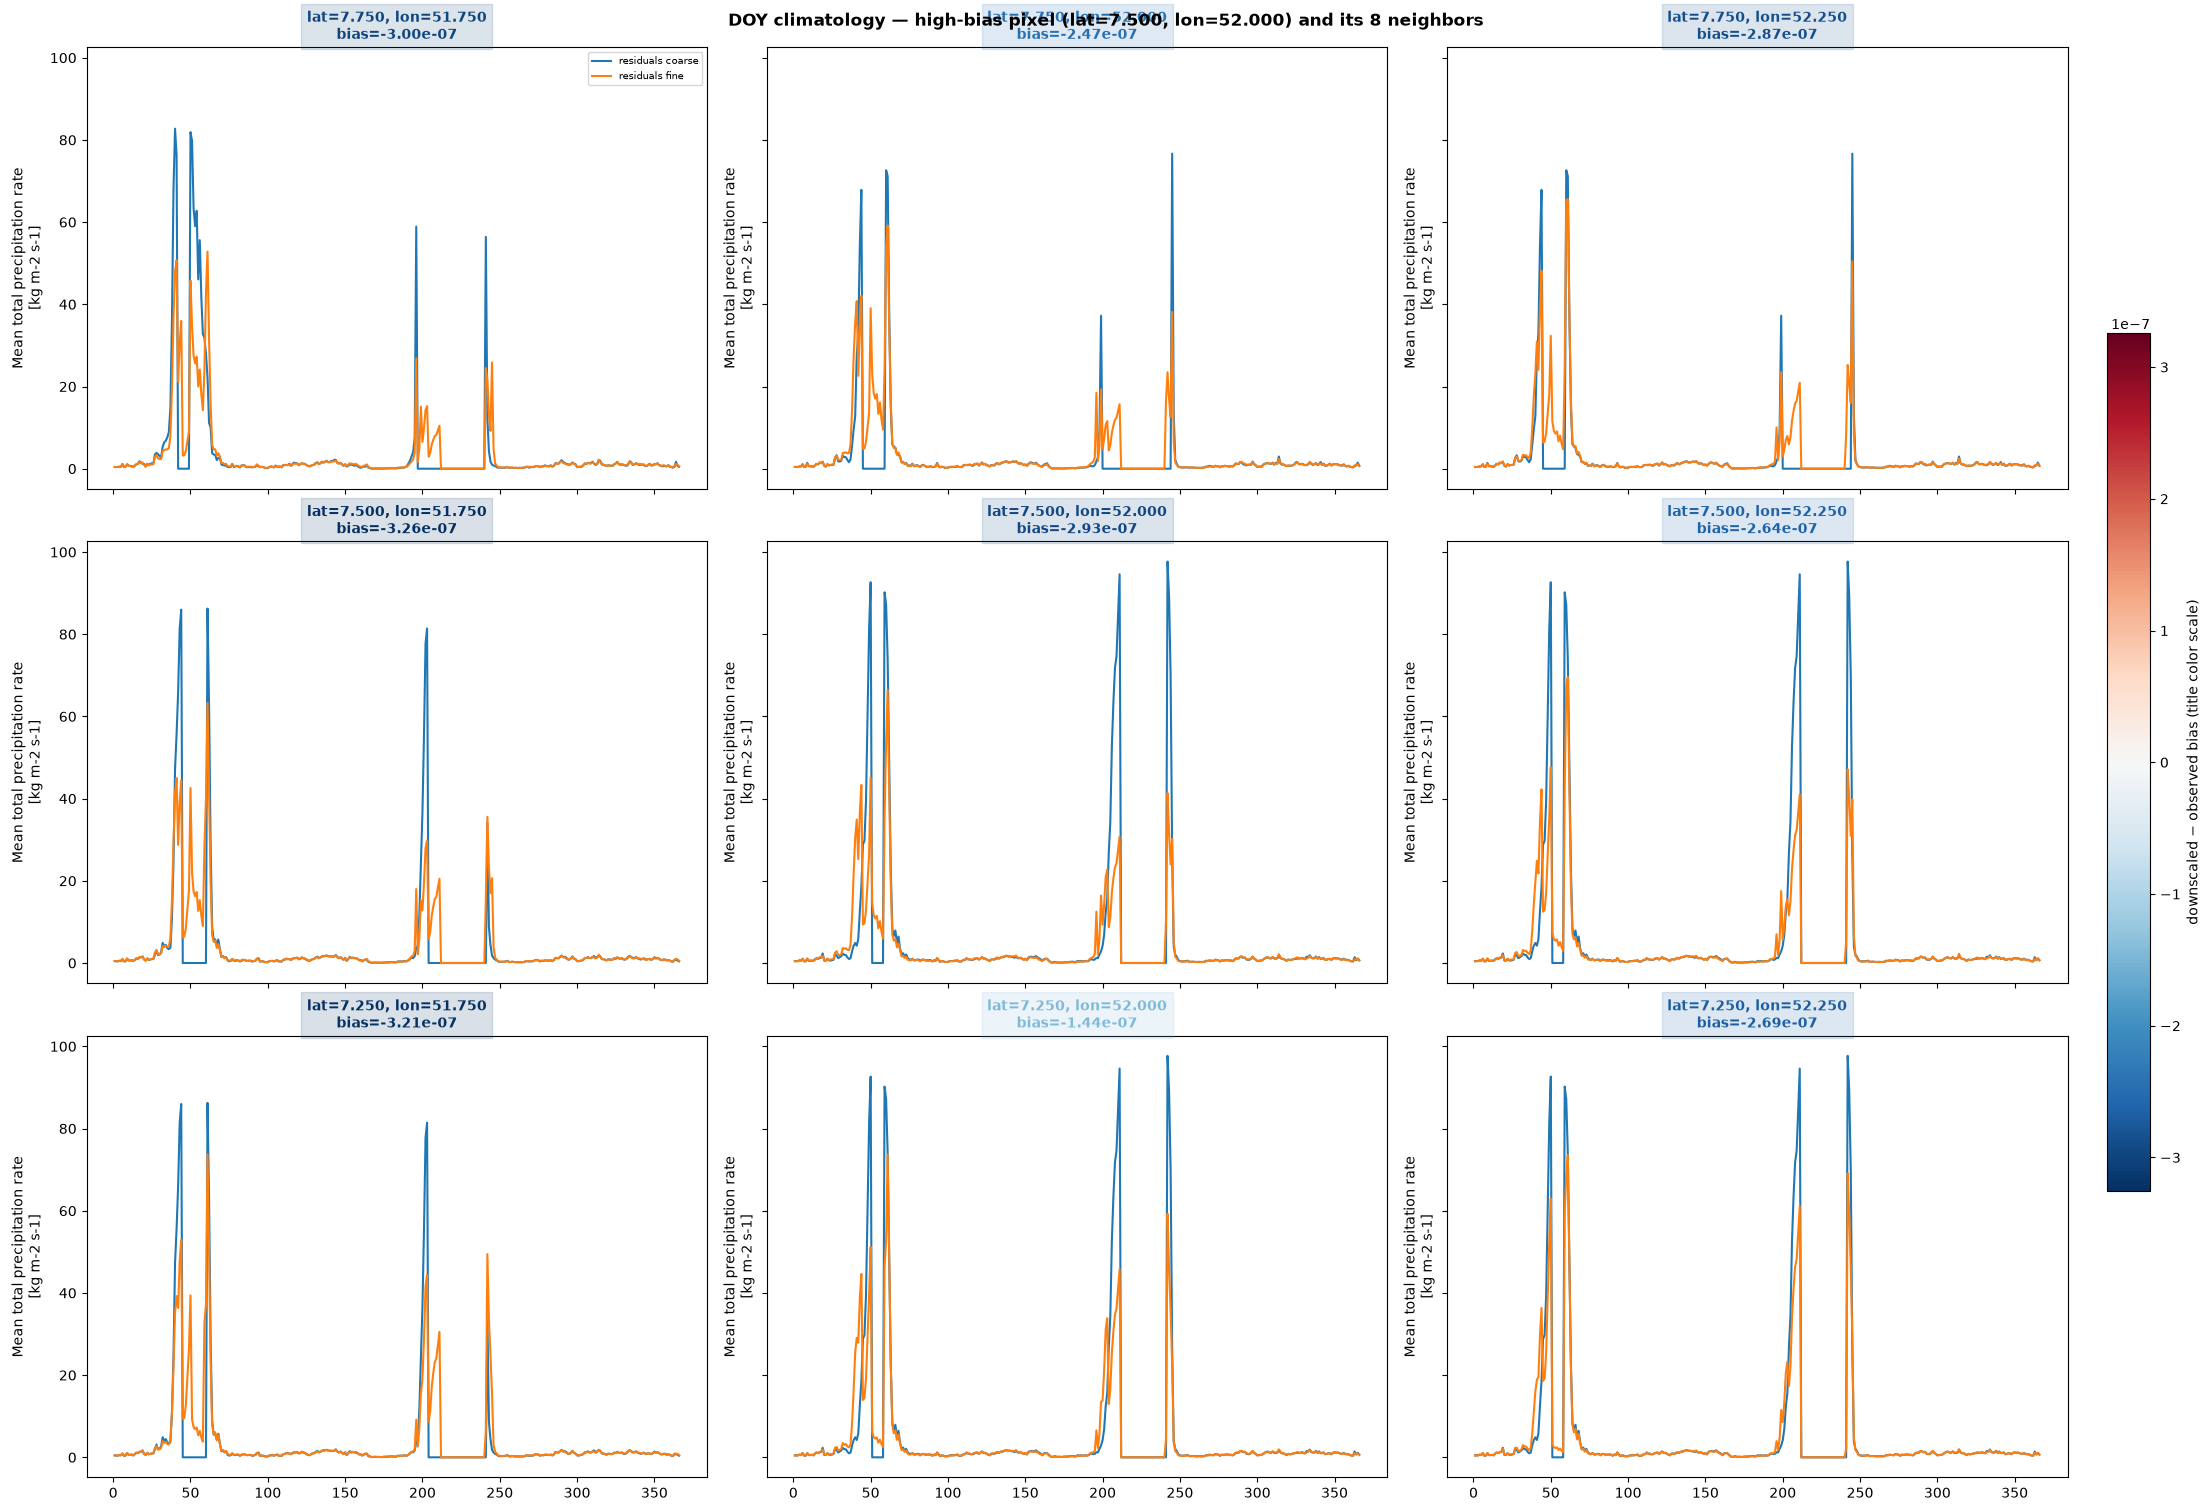

In [26]:
# FOCUS_LAT, FOCUS_LON = 2.7500, 45.2500  # the high-bias pixel identified in Part 3
FOCUS_LAT, FOCUS_LON = 7.500, 52.00
# Neighbor spacing from the fine grid's own coordinate spacing — robust to
# either ascending or descending lat/lon storage order, since offsets are
# applied to the numeric coordinate value, not the array index.
lat_step = float(np.median(np.abs(np.diff(downscaled["lat"].values))))
lon_step = float(np.median(np.abs(np.diff(downscaled["lon"].values))))

# Row/col layout mirrors the map: north (top) -> south (bottom), west (left) -> east (right).
grid_offsets = [
    [(+1, -1), (+1, 0), (+1, +1)],  # NW, N,  NE
    [(0, -1), (0, 0), (0, +1)],  #      W, center, E
    [(-1, -1), (-1, 0), (-1, +1)],  # SW, S,  SE
]

# ── Pass 1: resolve each panel's actual pixel + bias first, so panel titles ──
# can be colored on a scale shared across all 9 panels (a bias of the same
# magnitude should look equally "loud" no matter which panel it's in).
panels = []
for offset_row in grid_offsets:
    panel_row = []
    for dlat, dlon in offset_row:
        req_lat, req_lon = FOCUS_LAT + dlat * lat_step, FOCUS_LON + dlon * lon_step
        # Snap to the pixel's *actual* fine-grid coordinate labels (not the
        # requested lat/lon) so the title/bias lookup can't silently drift
        # onto the wrong cell.
        fine_pixel = downscaled.sel(lat=req_lat, lon=req_lon, method="nearest")
        actual_lat, actual_lon = float(fine_pixel["lat"]), float(fine_pixel["lon"])
        bias_val = float(downscaling_diff.sel(lat=actual_lat, lon=actual_lon, method="nearest"))
        panel_row.append({"lat": actual_lat, "lon": actual_lon, "bias": bias_val})
    panels.append(panel_row)

bias_vmax = max(abs(p["bias"]) for row in panels for p in row)
bias_norm = plt.Normalize(vmin=-bias_vmax, vmax=bias_vmax)
bias_cmap = plt.cm.RdBu_r  # matches the bias maps in Part 1: red = high bias, blue = low bias

fig, axes = plt.subplots(3, 3, figsize=(22, 15), sharex=True, sharey=True, layout="constrained")
for row_axes, panel_row in zip(axes, panels):
    for ax, panel in zip(row_axes, panel_row):
        lat, lon, bias_val = panel["lat"], panel["lon"], panel["bias"]

        residuals_coarse.sel(lat=lat, lon=lon, method="nearest").groupby(
            "time.dayofyear"
        ).mean().plot(ax=ax, label="residuals coarse")
        residuals_fine.sel(lat=lat, lon=lon, method="nearest").groupby(
            "time.dayofyear"
        ).mean().plot(ax=ax, label="residuals fine")

        # residuals_fine.sel(lat=lat, lon=lon, method="nearest").groupby(
        #     "time.dayofyear"
        # ).mean().plot(ax=ax, label="finescale residuals", color="green")

        # Loud bias indicator: bold + colored on a shared red(high)-blue(low)
        # scale, plus a light matching background so it reads at a glance.
        title_color = bias_cmap(bias_norm(bias_val))
        ax.set_title(
            f"lat={lat:.3f}, lon={lon:.3f}\nbias={bias_val:+.2e}",
            fontsize=10,
            fontweight="bold",
            color=title_color,
            backgroundcolor=(*title_color[:3], 0.15),
        )
        ax.set_xlabel("")

axes[0, 0].legend(fontsize=7, loc="upper right")
fig.colorbar(
    plt.cm.ScalarMappable(norm=bias_norm, cmap=bias_cmap),
    ax=axes,
    shrink=0.6,
    pad=0.02,
    label="downscaled − observed bias (title color scale)",
)
fig.suptitle(
    f"DOY climatology — high-bias pixel (lat={FOCUS_LAT:.3f}, lon={FOCUS_LON:.3f}) and its 8 neighbors",
    fontweight="bold",
    y=0.995,
)
plt.show()

Text(0.5, 1.0, 'Interpolated residuals for summer dry period')

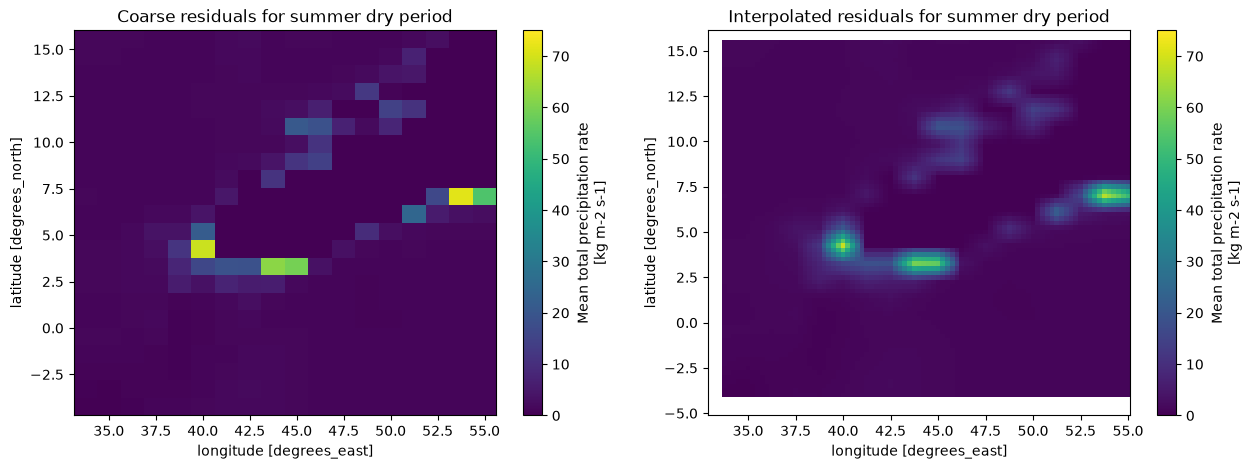

In [27]:
fig, axarr = plt.subplots(ncols=2, figsize=(15, 5))
residuals_coarse.groupby("time.dayofyear").mean().sel(dayofyear=slice(210, 220)).mean(
    dim="dayofyear"
).plot(ax=axarr[0], vmin=0, vmax=75)
axarr[0].set_title("Coarse residuals for summer dry period")
residuals_fine.groupby("time.dayofyear").mean().sel(dayofyear=slice(210, 220)).mean(
    dim="dayofyear"
).plot(ax=axarr[1], vmin=0, vmax=75)
axarr[1].set_title("Interpolated residuals for summer dry period")

Text(0.5, 1.0, 'Interpolated residuals for summer dry period')

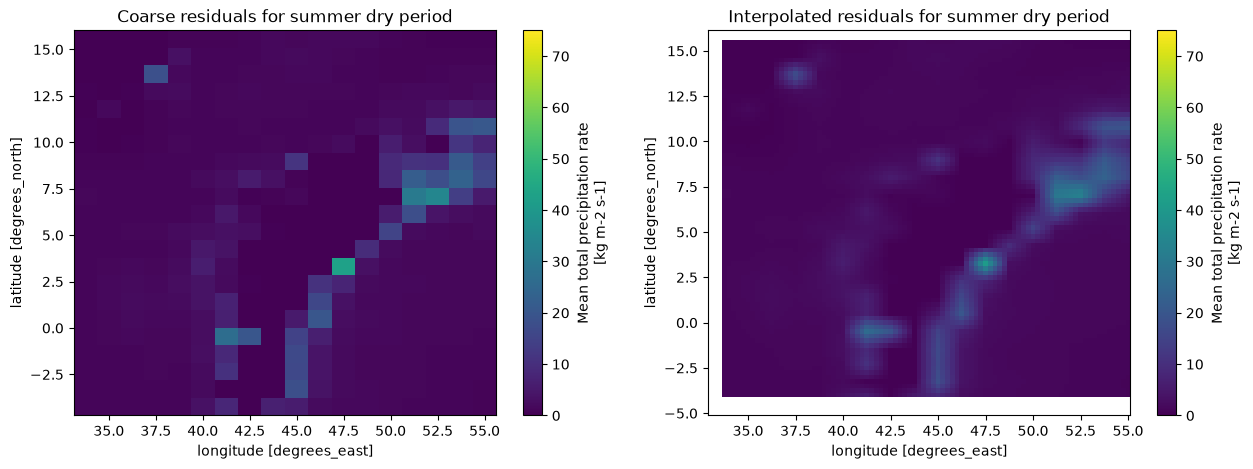

In [28]:
fig, axarr = plt.subplots(ncols=2, figsize=(15, 5))
residuals_coarse.groupby("time.dayofyear").mean().sel(dayofyear=slice(40, 50)).mean(
    dim="dayofyear"
).plot(ax=axarr[0], vmin=0, vmax=75)
axarr[0].set_title("Coarse residuals for summer dry period")
residuals_fine.groupby("time.dayofyear").mean().sel(dayofyear=slice(40, 50)).mean(
    dim="dayofyear"
).plot(ax=axarr[1], vmin=0, vmax=75)
axarr[1].set_title("Interpolated residuals for summer dry period")

A flag to find places like this could evaluate the finescale residuals and scan them for times when a seasonal cycle is reliably inflated. Below looks for when the residuals exceed 30 

Text(0.5, 1.0, 'Number of pixels flagged for each day of year')

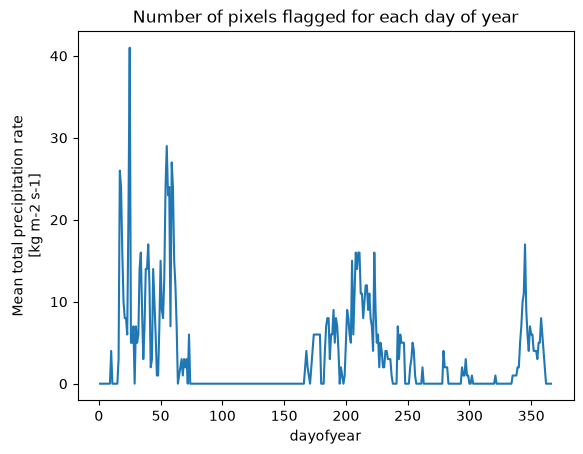

In [46]:
flag = (residuals_fine.groupby("time.dayofyear").mean() > 10) & (obs_fine_doy_means > 1e-6)
# residual for any pixel at any typical day of year is higher than 25 AND the seasonal cycle for that day of year isn't negligible
flag.sum(dim=["lat", "lon"]).plot()
plt.title("Number of pixels flagged for each day of year")

Text(0.5, 1.0, 'Pixels that, for at least one day of their year, may have anomalously high precipitation events')

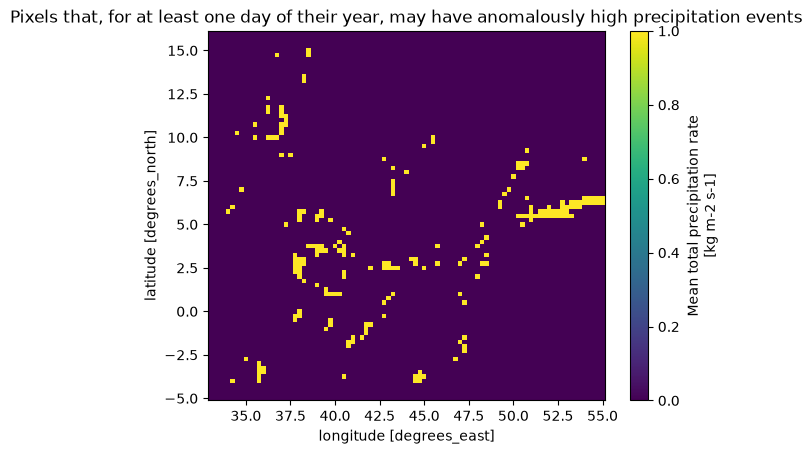

In [48]:
(flag.sum(dim="dayofyear") > 1).plot()
plt.title(
    "Pixels that, for at least one day of their year, may have anomalously high precipitation events"
)